# Initialize Project

Initialize GPU

In [ ]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


CUDA Available: True
GPU: Tesla T4


Mount google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


Import ultralytics

In [ ]:
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Prepare dataset and configuration files

The model is finetuned from the publicly available grozi3.2k dataset: https://universe.roboflow.com/feup-l3jz5/grozi-3.2k-testing/browse

Download train set

In [ ]:
# 1. Install the Kaggle library, inject Kaggle credentials
!pip install -q kaggle

import os
from google.colab import userdata

kaggle_username = userdata.get('KAGGLE_USERNAME')
kaggle_API = userdata.get('KAGGLE_API')
os.environ['KAGGLE_USERNAME'] = kaggle_username
os.environ['KAGGLE_KEY'] = kaggle_API

from kaggle.api.kaggle_api_extended import KaggleApi

# 2. Initialize and authenticate
api = KaggleApi()
api.authenticate()

# 4. Define the dataset and target folder
dataset_name = "thedatasith/sku110k-annotations"
download_path = "/content/SKU110K_Dataset" # '/content/' is Colab's default working directory

print(f"Pulling {dataset_name} into Colab...")

# 5. Download and unzip
api.dataset_download_files(
    dataset=dataset_name,
    path=download_path,
    unzip=True
)

print(f"Success! Data is ready at: {download_path}")

Create YAML file (YOLO required)

In [ ]:
import os

# 1. Define where you want to save the file
yaml_path = "/content/data.yaml"

# 2. Define the exact text that will go inside the file
yaml_content = """
path: /content/SKU110K_Dataset/SKU110K_fixed  # The absolute path to your dataset folder
train: images/train                          # Path to training images
val: images/val                              # Path to validation images
test: images/test                            # Path to test images (optional)

# Classes
nc: 1                                        # The total number of classes (SKU110K only has 1)
names: ['object']                            # The actual names of the classes
"""

# 3. Write the text into the file
with open(yaml_path, "w") as f:
    f.write(yaml_content.strip())

print(f"✅ Successfully generated YOLO config file at: {yaml_path}")

# Optional: Print the contents to verify it looks correct
print("\nFile contents:")
with open(yaml_path, "r") as f:
    print(f.read())

✅ Successfully generated YOLO config file at: /content/data.yaml

File contents:
path: /content/SKU110K_Dataset/SKU110K_fixed  # The absolute path to your dataset folder
train: images/train                          # Path to training images
val: images/val                              # Path to validation images
test: images/test                            # Path to test images (optional)

# Classes
nc: 1                                        # The total number of classes (SKU110K only has 1)
names: ['object']                            # The actual names of the classes


Train YOLO26 ultralytics, from 1st epoch:

In [ ]:
import os
import shutil
from google.colab import drive
from ultralytics import YOLO

# 1. Define backup callback function
def backup_every_5_epochs(trainer):
    """
    Checks the current epoch and saves to Google Drive if it's a multiple of 5.
    Even when resuming, 'trainer.epoch' knows the correct current epoch!
    """
    current_epoch = trainer.epoch + 1  # YOLO epochs are 0-indexed

    if current_epoch % 5 == 0:
        # Construct the path to where YOLO just saved the latest weights
        src_path = os.path.join(trainer.save_dir, 'weights', 'last.pt')

        dst_dir = '/content/drive/MyDrive/YOLO_SKU110K_Backups'
        dst_path = os.path.join(dst_dir, 'last.pt')

        os.makedirs(dst_dir, exist_ok=True)

        if os.path.exists(src_path):
            shutil.copy(src_path, dst_path)
            print(f"\n✅ [Auto-Backup] Epoch {current_epoch} complete: Successfully copied last.pt to Google Drive!\n")

# 2. Train YOLO with callback
print("Initializing YOLO Training...")
model = YOLO('yolo26s.pt')
# CRITICAL: Re-attach the callback to the model BEFORE telling it to resume
model.add_callback("on_train_epoch_end", backup_every_5_epochs)

# Train directly on the newly created yaml file
model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    name='yolo26_sku110k_augmented',

    # --- AUGMENTATION PARAMETERS ---
    degrees=15.0,        # Rotate images randomly by +/- 15 degrees
    translate=0.1,       # Translate (shift) images horizontally and vertically by 10%
    scale=0.5,           # Scale images by +/- 50%
    fliplr=0.5,          # 50% chance to flip images left-to-right
    flipud=0.0,          # 0% chance to flip up-down
    hsv_h=0.015,         # Adjust hue (color) slightly
    hsv_s=0.7,           # Adjust saturation heavily
    hsv_v=0.4,           # Adjust brightness (value) heavily
    mosaic=1.0,          # 100% chance to use Mosaic augmentation
    erasing=0.4          # 40% chance to randomly erase parts of the image
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully generated clean YOLO config at: /content/data.yaml
Initializing YOLO Training...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ra

Train YOLO26 Ultralytics, from checkpoint weight:

In [ ]:
import os
import shutil
from google.colab import drive
from ultralytics import YOLO

# Note: If Colab session disconnected, remember to re-run your
# data.yaml and dataset downloading scripts before running this block!

# 1. Backup call function
def backup_every_5_epochs(trainer):
    """
    Checks the current epoch and saves to Google Drive if it's a multiple of 5.
    Even when resuming, 'trainer.epoch' knows the correct current epoch!
    """
    current_epoch = trainer.epoch + 1

    if current_epoch % 5 == 0:
        src_path = os.path.join(trainer.save_dir, 'weights', 'last.pt')
        dst_dir = '/content/drive/MyDrive/YOLO_SKU110K_Backups'
        dst_path = os.path.join(dst_dir, 'last.pt')

        os.makedirs(dst_dir, exist_ok=True)

        if os.path.exists(src_path):
            shutil.copy(src_path, dst_path)
            print(f"\n✅ [Auto-Backup] Epoch {current_epoch} complete: Successfully copied last.pt to Google Drive!\n")

# 2. Load checkpoint and enable callback
checkpoint_path = '/content/drive/MyDrive/YOLO_SKU110K_Backups/last.pt'

print(f"Loading checkpoint from: {checkpoint_path}")
model = YOLO(checkpoint_path)

# CRITICAL: Re-attach the callback to the model BEFORE telling it to resume
model.add_callback("on_train_epoch_end", backup_every_5_epochs)

# 3. Resume training:
print("Resuming training with 5-epoch auto-backup enabled...")
# Trigger the resume
model.train(resume=True)

# Test model

Model accuracy:

In [ ]:
from ultralytics import YOLO

# 1. Load best trained weights
best_model_path = '/content/runs/detect/yolo26_sku110k_augmented/weights/best.pt'
model = YOLO(best_model_path)

print("Starting evaluation over the entire test dataset...")

# 2. Run the evaluation
metrics = model.val(
    data='/content/data.yaml',
    split='test',
    imgsz=640,
    batch=16       # Adjust this based on your Colab GPU memory
)

# 3. Print the final scores
print("\n🏁 TESTING COMPLETE 🏁")
print(f"Final mAP50 score:    {metrics.box.map50:.4f}")
print(f"Final mAP50-95 score: {metrics.box.map:.4f}")

Starting evaluation over the entire test dataset...
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 189.9±55.9 MB/s, size: 1408.2 KB)
val: Scanning /content/SKU110K_Dataset/SKU110K_fixed/labels/test.cache... 2920 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2920/2920 371.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 183/183 1.2it/s 2:38
                   all       2920     429411      0.911      0.866      0.923       0.57
Speed: 1.3ms preprocess, 7.5ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val-3

🏁 TESTING COMPLETE 🏁
Final mAP50 score:    0.9235
Final mAP50-95 score: 0.5700


Visualize with bounding box:

Pulling images from: /content/runs/detect/predict



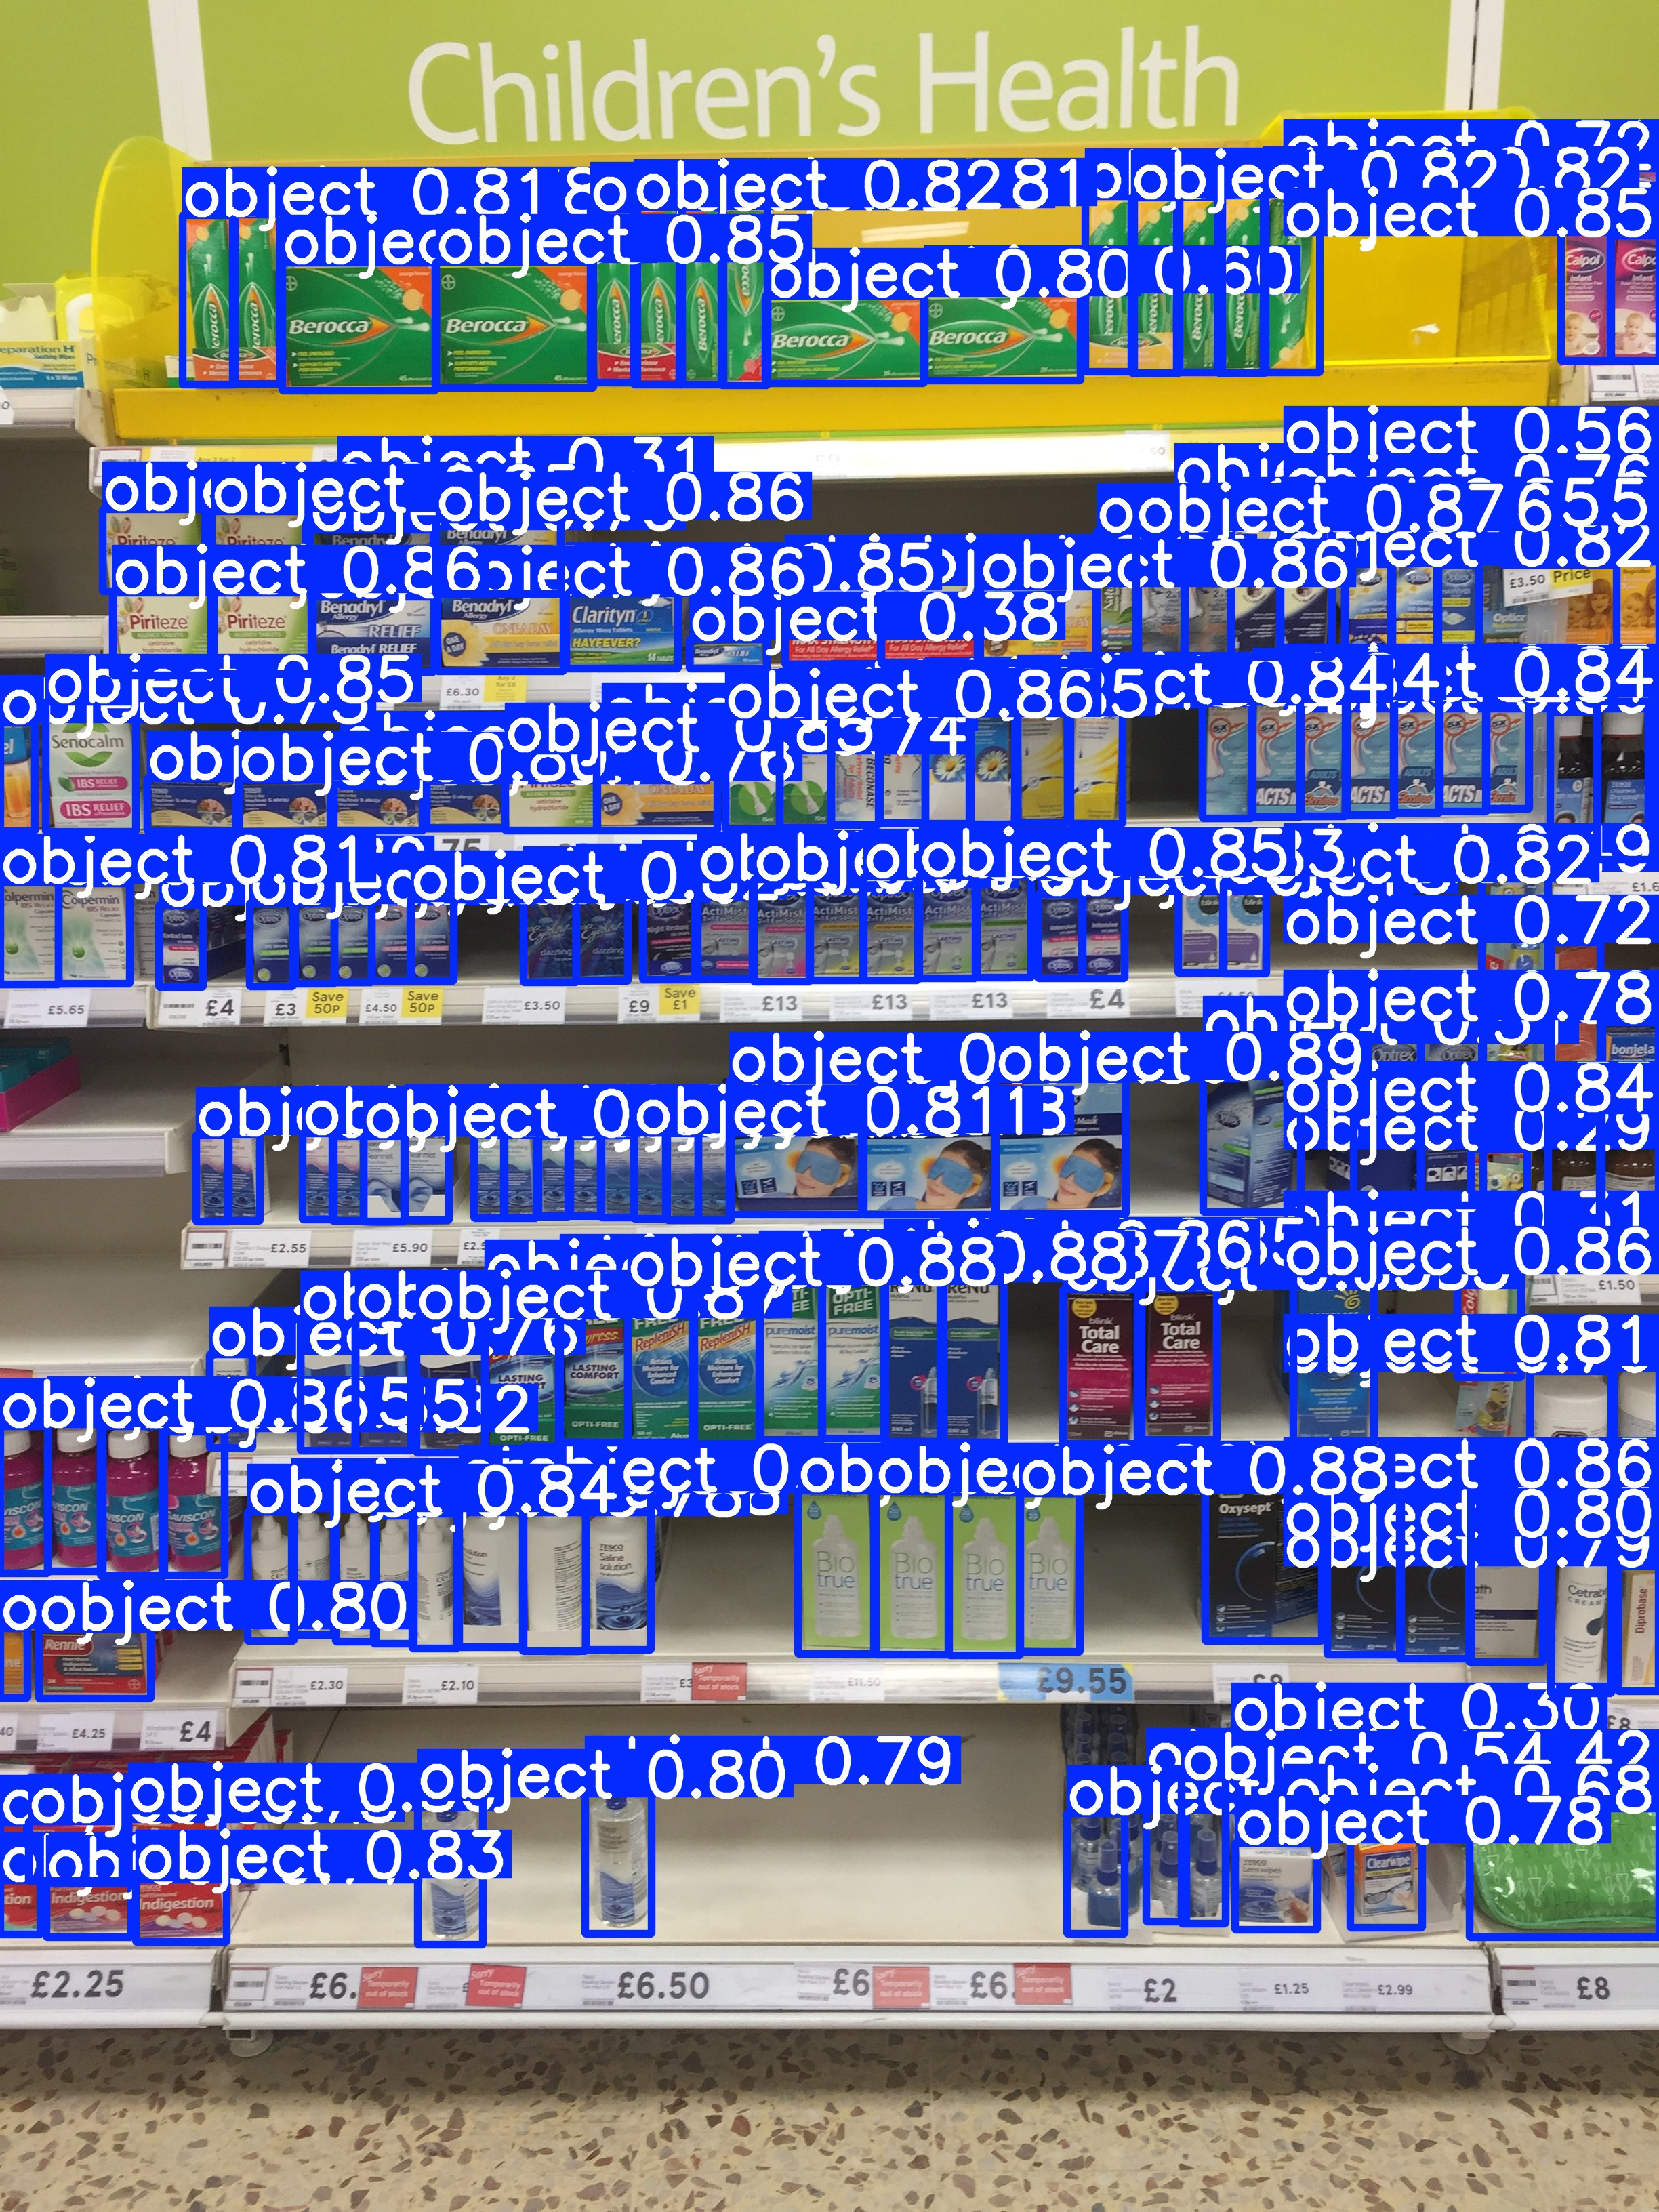

In [ ]:
import os
import glob
from IPython.display import Image, display

# 1. Find all YOLO prediction folders
predict_dirs = glob.glob('/content/runs/detect/predict*')

if not predict_dirs:
    print("No prediction folders found! Make sure you ran model.predict() first.")
else:
    # 2. Automatically select the most recently created folder
    latest_dir = max(predict_dirs, key=os.path.getmtime)
    print(f"Pulling images from: {latest_dir}\n")

    # 3. Get all the .jpg images inside that folder
    image_files = glob.glob(f"{latest_dir}/*.jpg")

    if image_files:
        # 4. Display the first image!
        # (Change [0] to [1] or [2] to see the next images in the list)
        display(Image(filename=image_files[0], width=800))
    else:
        print("The folder exists, but no .jpg images were found inside.")